# Prophet Forecasting with Weather Features

This notebook trains and evaluates a Prophet time-series model using weather features as extra regressors.

It includes:

- data preparation and validation
- chronological train/test split
- weather regressors
- evaluation metrics and a naive baseline
- forecast plots and component plots
- optional future forecasting using weather forecast data

Update the configuration cell so its column names match your dataset.

In [1]:
# Install packages if needed
# %pip install prophet pandas numpy matplotlib scikit-learn

## 1. Imports

In [21]:
import matplotlib.pyplot as plt

In [22]:
import numpy as np
import pandas as pd
#import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Load or provide your merged DataFrame

Your DataFrame should have one row per timestamp and include:

- a date/time column
- the target you want to forecast
- weather columns such as temperature, rainfall, and wind speed

Example loading code is included below. Uncomment and adapt it if needed.

In [23]:
# Example: load a CSV file
df = pd.read_excel("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/RoadTrafficCollisions/df_ts_1.xlsx")
df.drop(columns = 'Unnamed: 0', inplace =True)
df.head(3)
df = df[df['Date']<'2025-01-01']

Task was destroyed but it is pending!
task: <Task pending name='Task-185' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-186' coro=<Kernel.shell_main() running at C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\descriptors\serialisable.py:60: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  if key.startswith('{'):
Task was destroyed but it is pending!
task: <Task pending name='Task-186' coro=<Kernel.shell_main() running at C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-package

## 3. Configuration

Change these values to match your data.

In [24]:
# ============================================================
# CONFIGURATION — CHANGE THESE TO MATCH YOUR DATA
# ============================================================

DATE_COLUMN = "Date"          # e.g. "time", "date", "timestamp"
TARGET_COLUMN = "Incident_Count"      # e.g. "sales", "energy_usage", "bookings"

WEATHER_COLUMNS = [
    'Tmax °C', 
    'Tmin °C', 
    'Daily Tmean °C', 
    'Ground frost 0/1', 
    'Max < 0 °C',
    'Rainfall mm raw incl traces',
    'Sunshine duration h'
]

# Size of the final chronological test period
TEST_DAYS = 30

# Usually start with "additive".
# Try "multiplicative" if seasonal variation grows as the target grows.
SEASONALITY_MODE = "additive"

# Optional: a separate DataFrame containing future weather forecasts.
# It must include DATE_COLUMN plus every weather feature listed above.
# Leave as None if you only want to evaluate on the held-out test set.

#future_weather_df = None

## 4. Prepare the data for Prophet

In [25]:
required_columns = [DATE_COLUMN, TARGET_COLUMN] + WEATHER_COLUMNS
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(
        f"These columns are missing from df: {missing_columns}\n"
        f"Available columns: {df.columns.tolist()}"
    )

prophet_df = df[required_columns].copy()

# Prophet requires these exact names:
# ds = date/timestamp
# y = target to forecast
prophet_df = prophet_df.rename(
    columns={
        DATE_COLUMN: "ds",
        TARGET_COLUMN: "y"
    }
)

prophet_df["ds"] = pd.to_datetime(prophet_df["ds"], errors="coerce")
prophet_df["y"] = pd.to_numeric(prophet_df["y"], errors="coerce")

for col in WEATHER_COLUMNS:
    prophet_df[col] = pd.to_numeric(prophet_df[col], errors="coerce")

# Drop rows without usable date or target values
prophet_df = (
    prophet_df
    .dropna(subset=["ds", "y"])
    .sort_values("ds")
    .reset_index(drop=True)
)

# Prophet expects one row per timestamp
if prophet_df["ds"].duplicated().any():
    duplicate_dates = prophet_df.loc[
        prophet_df["ds"].duplicated(), "ds"
    ].head()

    raise ValueError(
        "Duplicate timestamps found. Aggregate your data first "
        "(for example, one row per day or hour).\n"
        f"Example duplicate timestamps:\n{duplicate_dates}"
    )

if len(prophet_df) < 20:
    raise ValueError(
        "Too little data after cleaning. Prophet needs a longer historical series."
    )

print("Data range:")
print(f"Start: {prophet_df['ds'].min()}")
print(f"End:   {prophet_df['ds'].max()}")
print(f"Rows:  {len(prophet_df)}")

prophet_df.head()

Data range:
Start: 2015-01-01 00:00:00
End:   2024-12-31 00:00:00
Rows:  3653


,ds,y,Tmax °C,Tmin °C,Daily Tmean °C,Ground frost 0/1,Max < 0 °C,Rainfall mm raw incl traces,Sunshine duration h
0,2015-01-01,3,13.5,2.6,8.1,0.0,0,0.9,0.0
1,2015-01-02,0,9.2,5.9,7.6,0.0,0,10.7,6.5
2,2015-01-03,0,4.9,3.0,4.0,1.0,0,3.7,0.0
3,2015-01-04,4,7.0,-1.5,2.8,1.0,0,0.2,0.0
4,2015-01-05,2,9.8,-0.8,4.5,1.0,0,0.2,0.0


## 5. Create a chronological train/test split

Time-series data must not be split randomly. The model is trained on earlier dates and tested on later unseen dates.

In [26]:
#cutoff_date = prophet_df["ds"].max() - pd.Timedelta(days=TEST_DAYS) ## for realtime cuttoff dates
cutoff_date = prophet_df["ds"].max()  - pd.Timedelta(days=len(prophet_df["ds"])*0.2)  ## for our set date range max <=2025
train = prophet_df[prophet_df["ds"] <= cutoff_date].copy()
test = prophet_df[prophet_df["ds"] > cutoff_date].copy()

if train.empty or test.empty:
    raise ValueError(
        "Train or test set is empty. Reduce TEST_DAYS or check your dates."
    )

print("Train period:")
print(f"{train['ds'].min()} to {train['ds'].max()} ({len(train)} rows)")

print("\nTest period:")
print(f"{test['ds'].min()} to {test['ds'].max()} ({len(test)} rows)")

Train period:
2015-01-01 00:00:00 to 2022-12-31 00:00:00 (2922 rows)

Test period:
2023-01-01 00:00:00 to 2024-12-31 00:00:00 (731 rows)


## 6. Handle missing weather values

For historical evaluation, interpolation is a practical fallback.

For genuine future production forecasts, use weather forecasts from a weather API or forecast data source rather than filling future weather with averages.

In [27]:
def fill_weather_values(dataframe, weather_columns):
    dataframe = dataframe.copy().sort_values("ds")

    dataframe[weather_columns] = (
        dataframe[weather_columns]
        .interpolate(method="linear", limit_direction="both")
        .ffill()
        .bfill()
    )

    remaining_missing = dataframe[weather_columns].isna().sum()
    remaining_missing = remaining_missing[remaining_missing > 0]

    if not remaining_missing.empty:
        raise ValueError(
            f"Weather columns still contain missing values:\n{remaining_missing}"
        )

    return dataframe


train = fill_weather_values(train, WEATHER_COLUMNS)
test = fill_weather_values(test, WEATHER_COLUMNS)


## 7. Keep only usable weather regressors

Prophet cannot use a regressor that is constant throughout the training data.

In [28]:
valid_weather_columns = []
skipped_weather_columns = []

for col in WEATHER_COLUMNS:
    if train[col].nunique(dropna=True) > 1:
        valid_weather_columns.append(col)
    else:
        skipped_weather_columns.append(col)

if skipped_weather_columns:
    print("Skipping constant weather columns:")
    print(skipped_weather_columns)

print("Weather regressors used:")
print(valid_weather_columns)

Weather regressors used:
['Tmax °C', 'Tmin °C', 'Daily Tmean °C', 'Ground frost 0/1', 'Max < 0 °C', 'Rainfall mm raw incl traces', 'Sunshine duration h']


## 8. Build and fit Prophet

In [29]:
def build_prophet_model(regressors):
    model = Prophet(
        seasonality_mode=SEASONALITY_MODE,
        yearly_seasonality="auto",
        weekly_seasonality="auto",
        daily_seasonality="auto",
        interval_width=0.95
    )

    for regressor in regressors:
        model.add_regressor(regressor)

    return model


model = build_prophet_model(valid_weather_columns)

train_columns = ["ds", "y"] + valid_weather_columns
model.fit(train[train_columns])

12:37:18 - cmdstanpy - INFO - Chain [1] start processing
12:37:19 - cmdstanpy - INFO - Chain [1] done processing


## 9. Forecast the held-out test set

The target `y` is deliberately excluded from the future DataFrame so this acts like a genuine forecast.

For the historical test set, it is valid to use the actual weather that occurred. For a real future forecast, you need forecast weather values instead.

In [30]:
test_future = test[["ds"] + valid_weather_columns].copy()

forecast_test = model.predict(test_future)

results = test[["ds", "y"]].merge(
    forecast_test[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds",
    how="left"
)

results.head()

,ds,y,yhat,yhat_lower,yhat_upper
0,2023-01-01,1,0.972531,-1.244962,3.200828
1,2023-01-02,2,1.080674,-1.087286,3.260318
2,2023-01-03,2,0.933050,-1.386192,3.110665
3,2023-01-04,0,0.913878,-1.304123,3.204931
4,2023-01-05,1,0.954110,-1.198548,3.058624


## 10. Evaluate performance

In [31]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid = denominator != 0

    return np.mean(
        np.abs(y_true[valid] - y_pred[valid]) / denominator[valid]
    ) * 100


mae = mean_absolute_error(results["y"], results["yhat"])
rmse = np.sqrt(mean_squared_error(results["y"], results["yhat"]))
smape_score = smape(results["y"], results["yhat"])

# Naive benchmark: predicts the final training value for every test row
naive_predictions = np.repeat(train["y"].iloc[-1], len(test))
naive_mae = mean_absolute_error(test["y"], naive_predictions)
naive_rmse = np.sqrt(mean_squared_error(test["y"], naive_predictions))

metrics = pd.DataFrame({
    "Model": ["Prophet + weather", "Naive baseline"],
    "MAE": [mae, naive_mae],
    "RMSE": [rmse, naive_rmse],
    "sMAPE (%)": [smape_score, np.nan]
})

print(metrics.round(3))

results.to_csv("prophet_test_predictions.csv", index=False)
print("\nSaved test predictions to: prophet_test_predictions.csv")

               Model    MAE   RMSE  sMAPE (%)
0  Prophet + weather  0.922  1.137     92.115
1     Naive baseline  1.168  1.398        NaN

Saved test predictions to: prophet_test_predictions.csv


## 11. Plot actual versus predicted values

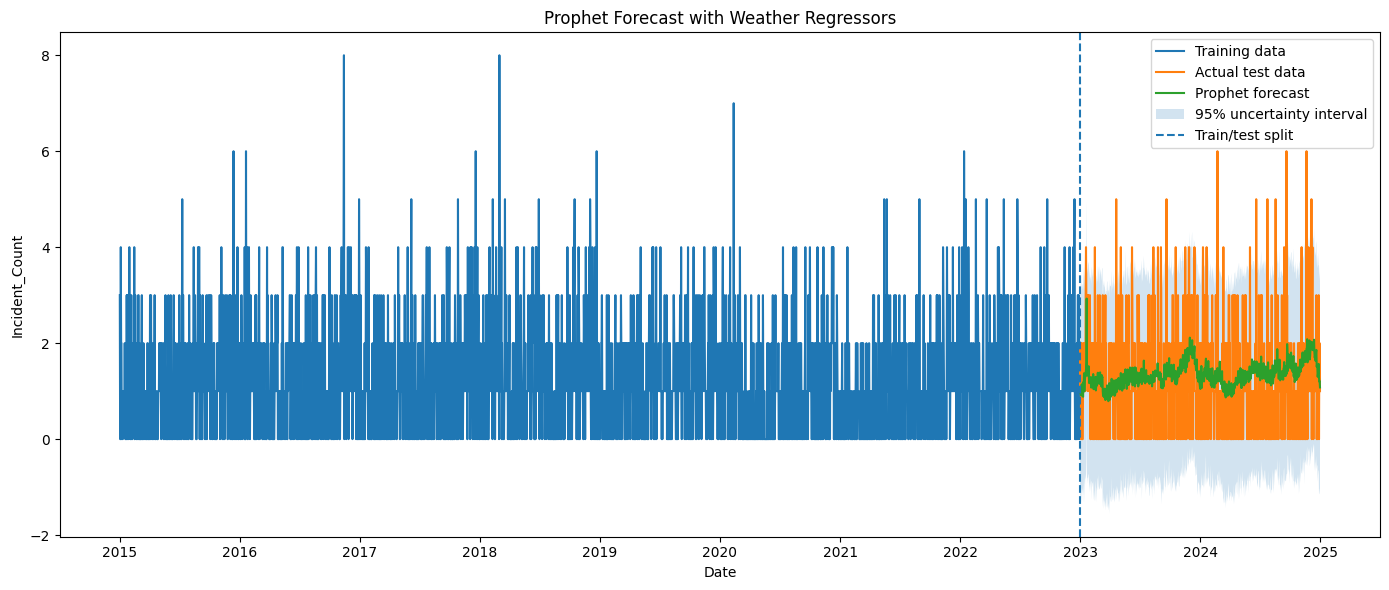

In [32]:
plt.figure(figsize=(14, 6))

plt.plot(train["ds"], train["y"], label="Training data")
plt.plot(test["ds"], test["y"], label="Actual test data")
plt.plot(results["ds"], results["yhat"], label="Prophet forecast")

plt.fill_between(
    results["ds"],
    results["yhat_lower"],
    results["yhat_upper"],
    alpha=0.2,
    label="95% uncertainty interval"
)

plt.axvline(
    cutoff_date,
    linestyle="--",
    label="Train/test split"
)

plt.title("Prophet Forecast with Weather Regressors")
plt.xlabel("Date")
plt.ylabel(TARGET_COLUMN)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Inspect model components

This shows the learned trend, seasonal patterns, and the effects of any configured components.

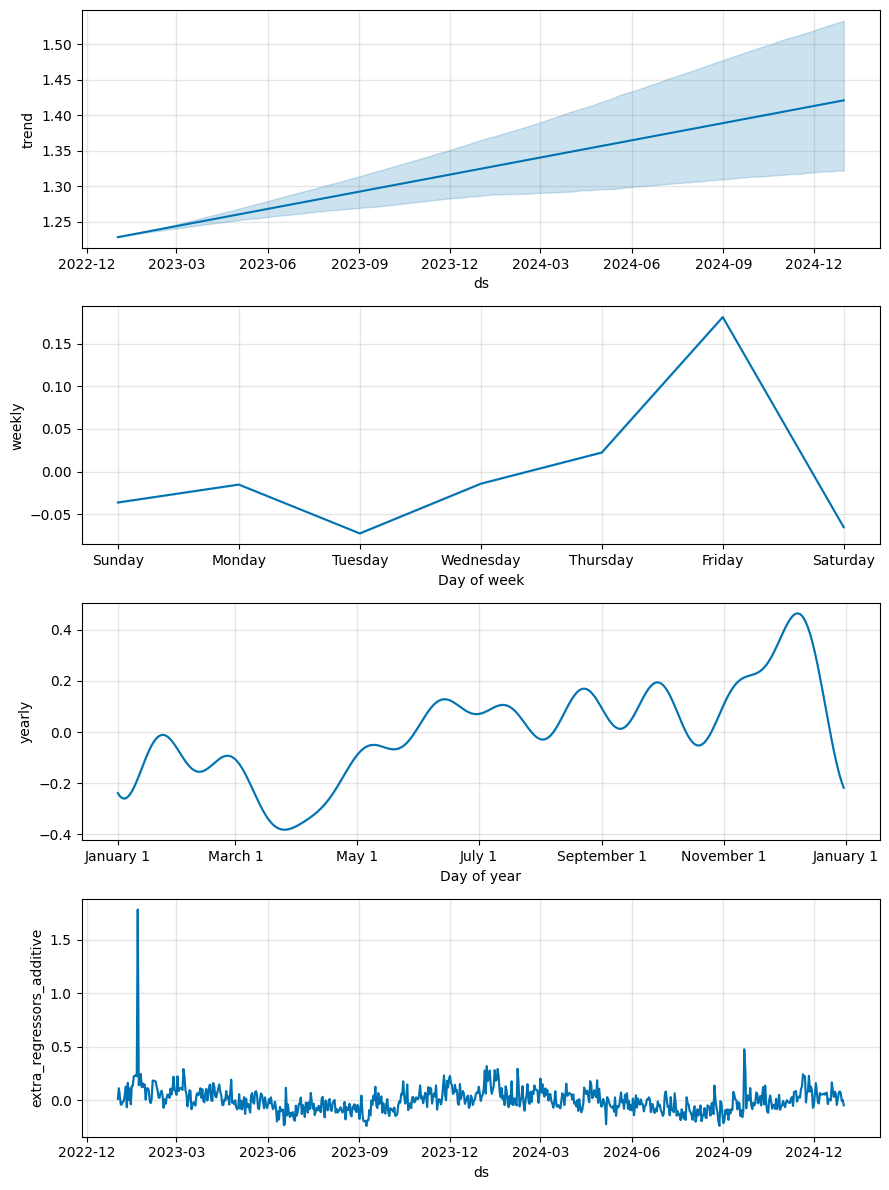

In [33]:
model.plot_components(forecast_test)
plt.tight_layout()
plt.show()

## 13. Optional: Forecast future dates with weather forecasts

Set `future_weather_df` in the configuration section. It must contain the date column and all weather columns used by the model.

Example:

```python
future_weather_df = pd.read_csv("future_weather_forecast.csv")
```

Do not use unknown future observed weather when making real production forecasts. Use weather forecasts.

In [34]:

df = pd.read_excel("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/RoadTrafficCollisions/df_ts_1.xlsx")
df.drop(columns = 'Unnamed: 0', inplace =True)
df.head(3)
#df = df[df['Date']>='2025-01-01']

future_weather_df = df.copy()

if future_weather_df is not None:

    full_data = fill_weather_values(prophet_df, WEATHER_COLUMNS)

    final_model = build_prophet_model(valid_weather_columns)
    final_model.fit(full_data[["ds", "y"] + valid_weather_columns])

    future_weather = future_weather_df.copy()

    if DATE_COLUMN not in future_weather.columns:
        raise ValueError(
            f"future_weather_df must contain '{DATE_COLUMN}'."
        )

    missing_future_weather = [
        col for col in valid_weather_columns
        if col not in future_weather.columns
    ]

    if missing_future_weather:
        raise ValueError(
            f"future_weather_df is missing: {missing_future_weather}"
        )

    future_weather = future_weather.rename(columns={DATE_COLUMN: "ds"})
    future_weather["ds"] = pd.to_datetime(
        future_weather["ds"],
        errors="coerce"
    )

    for col in valid_weather_columns:
        future_weather[col] = pd.to_numeric(
            future_weather[col],
            errors="coerce"
        )

    future_weather = future_weather.dropna(
        subset=["ds"] + valid_weather_columns
    ).sort_values("ds")

    # Keep only dates after the final historical observation
    future_weather = future_weather[
        future_weather["ds"] > full_data["ds"].max()
    ].copy()

    if future_weather.empty:
        raise ValueError(
            "No future dates found in future_weather_df."
        )

    production_forecast = final_model.predict(
        future_weather[["ds"] + valid_weather_columns]
    )

    production_output = production_forecast[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ].copy()

    production_output.to_csv(
        "prophet_future_forecast.csv",
        index=False
    )

    print("Saved future forecast to: prophet_future_forecast.csv")
    display(production_output)#.head())

else:
    print(
        "future_weather_df is None, so no genuine future forecast was created."
    )

12:37:24 - cmdstanpy - INFO - Chain [1] start processing
12:37:25 - cmdstanpy - INFO - Chain [1] done processing


Saved future forecast to: prophet_future_forecast.csv


,ds,yhat,yhat_lower,yhat_upper
0,2025-01-01,1.022034,-1.158704,3.189525
1,2025-01-02,1.288623,-0.952182,3.544699
2,2025-01-04,1.173440,-1.016177,3.345299
3,2025-01-05,1.062469,-1.355180,3.194795
4,2025-01-06,1.039844,-1.047824,3.209253
...,...,...,...,...
298,2025-12-23,1.257236,-0.945737,3.338076
299,2025-12-24,1.394893,-0.957682,3.601515
300,2025-12-25,1.485953,-0.669235,3.771156
301,2025-12-28,1.089973,-1.294980,3.171004


In [35]:
production_output

,ds,yhat,yhat_lower,yhat_upper
0,2025-01-01,1.022034,-1.158704,3.189525
1,2025-01-02,1.288623,-0.952182,3.544699
2,2025-01-04,1.173440,-1.016177,3.345299
3,2025-01-05,1.062469,-1.355180,3.194795
4,2025-01-06,1.039844,-1.047824,3.209253
...,...,...,...,...
298,2025-12-23,1.257236,-0.945737,3.338076
299,2025-12-24,1.394893,-0.957682,3.601515
300,2025-12-25,1.485953,-0.669235,3.771156
301,2025-12-28,1.089973,-1.294980,3.171004


<Axes: xlabel='ds'>

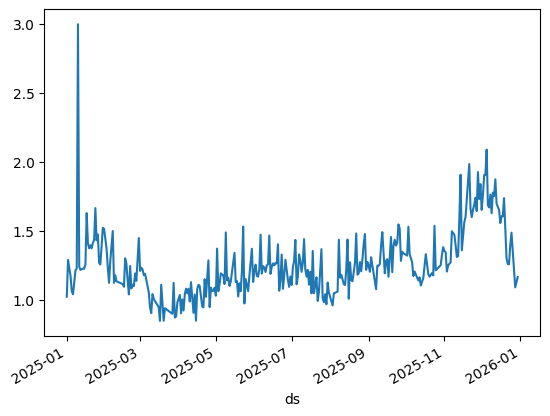

In [36]:
df_2025_prod = df_2025 = production_output.set_index("ds")
df_2025_prod['yhat'].plot()


In [37]:
#df = df.set_index("Date")

<Axes: xlabel='ds'>

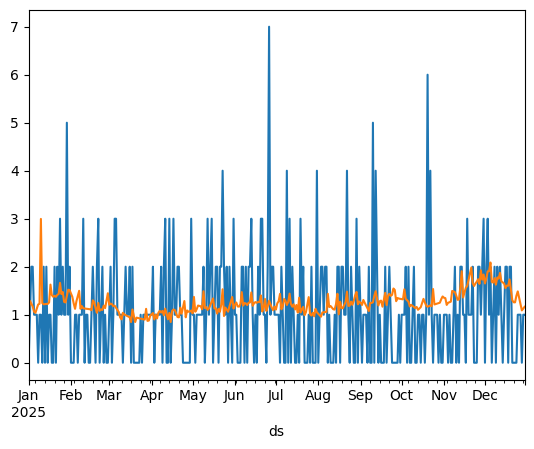

In [38]:
df_2025 = df[df["Date"]>='20250101'].set_index("Date")
df_2025['Incident_Count'].plot()
df_2025_prod['yhat'].plot()
#df_2025_prod['yhat_lower'].plot()
#df_2025_prod['yhat_upper'].plot()